<a href="https://colab.research.google.com/github/JeevanRaj17/ai-robot-for-vanilla-plant-using-cnn-model-/blob/main/G21imagepro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install kagglehub
!pip install matplotlib seaborn scikit-learn

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "mihsanpermana/vanilla-plant-disease-image-dataset"
    )

print("Path to dataset files:", path)

100%|██████████| 4.06G/4.06G [00:49<00:00, 88.7MB/s]

Extracting files...


In [ ]:
dataset_path = path
print(dataset_path)

/kaggle/input/vanilla-plant-disease-image-dataset


In [ ]:
import os

for root, dirs, files in os.walk(dataset_path):
    print(root)

/kaggle/input/vanilla-plant-disease-image-dataset
/kaggle/input/vanilla-plant-disease-image-dataset/vanilla dataset
/kaggle/input/vanilla-plant-disease-image-dataset/vanilla dataset/black spots
/kaggle/input/vanilla-plant-disease-image-dataset/vanilla dataset/rotten stem
/kaggle/input/vanilla-plant-disease-image-dataset/vanilla dataset/Healthy
/kaggle/input/vanilla-plant-disease-image-dataset/vanilla dataset/red spots


In [ ]:
dataset_path = "/root/.cache/kagglehub/datasets/mihsanpermana/vanilla-plant-disease-image-dataset/versions/1/vanilla dataset"

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
        validation_split=0.2,
            subset="training",
                seed=SEED,
                    image_size=IMG_SIZE,
                        batch_size=BATCH_SIZE
                        )

Found 2000 files belonging to 4 classes.
Using 1600 files for training.


In [ ]:
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
      dataset_path,
          validation_split=0.2,
              subset="validation",
                  seed=SEED,
                      image_size=IMG_SIZE,
                          batch_size=BATCH_SIZE
                          )

Found 2000 files belonging to 4 classes.
Using 400 files for validation.


In [ ]:
class_names = train_dataset.class_names

print("Classes:")
print(class_names)

Classes:
['Healthy', 'black spots', 'red spots', 'rotten stem']


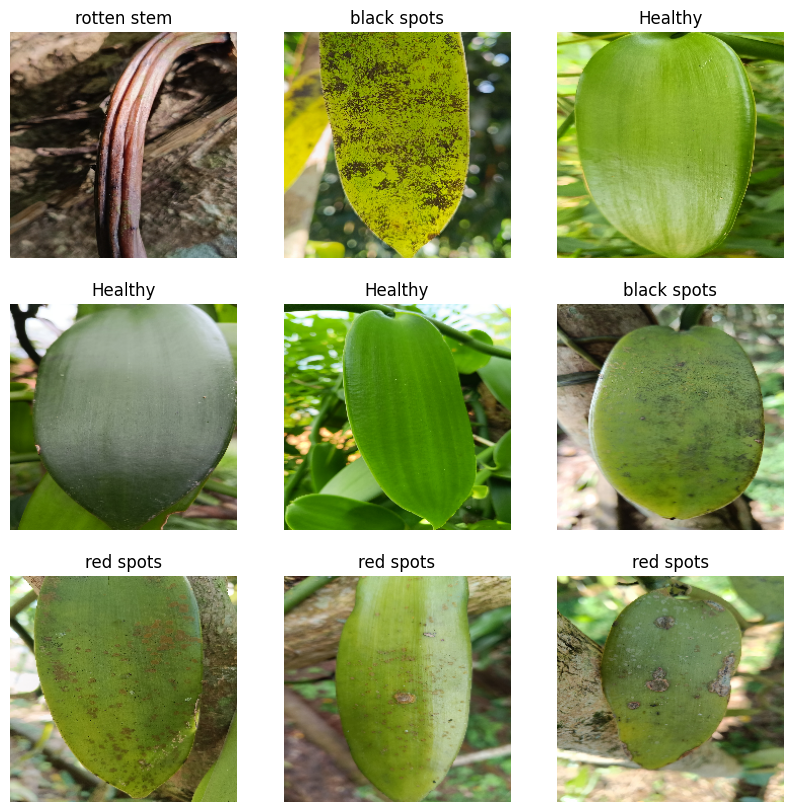

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
      layers.RandomFlip("horizontal"),
          layers.RandomRotation(0.15),
              layers.RandomZoom(0.15),
                  layers.RandomContrast(0.1)
                  ])

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1)
])

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
print("Trainable parameters:",
      sum(tf.keras.backend.count_params(w)
          for w in model.trainable_weights))

Trainable parameters: 164484


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_vanilla_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [ ]:
history = model.fit(
      train_dataset,
          validation_data=validation_dataset,
              epochs=20,
                  callbacks=[early_stop, checkpoint]
                  )

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 172ms/step - accuracy: 0.2406 - loss: 1.4355 - val_accuracy: 0.2250 - val_loss: 1.3886
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.2469 - loss: 1.3918 - val_accuracy: 0.2250 - val_loss: 1.3935
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.2350 - loss: 1.3881 - val_accuracy: 0.2250 - val_loss: 1.3867
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.2544 - loss: 1.3866 - val_accuracy: 0.2250 - val_loss: 1.3868
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.2512 - loss: 1.3865 - val_accuracy: 0.2300 - val_loss: 1.3869
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.2469 - loss: 1.3868 - val_accuracy: 0.2300 - val_loss: 1.3871
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.2556 - loss: 1.3865 - val_accuracy: 0.2300 - val_loss: 1.3872
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.2531 - loss: 1.3867 - val_accuracy: 0.2250 

In [ ]:
print("Epochs completed:", len(history.history['loss']))
print("Best training accuracy:", max(history.history['accuracy']))
print("Best validation accuracy:", max(history.history['val_accuracy']))

Epochs completed: 8
Best training accuracy: 0.25562500953674316
Best validation accuracy: 0.23000000417232513


In [ ]:
for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)
    print("Image minimum:", tf.reduce_min(images).numpy())
    print("Image maximum:", tf.reduce_max(images).numpy())
    print("Labels:", labels.numpy())
    print("Unique labels:", np.unique(labels.numpy()))

Image shape: (32, 224, 224, 3)
Image minimum: 0.0
Image maximum: 1.0
Labels: [1 0 1 3 3 0 0 0 2 1 0 3 3 1 0 0 3 2 0 0 0 1 3 1 1 2 3 3 1 3 3 1]
Unique labels: [0 1 2 3]


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

dataset_path = "/root/.cache/kagglehub/datasets/mihsanpermana/vanilla-plant-disease-image-dataset/vanilla dataset"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

print("Classes:", class_names)

FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/mihsanpermana/vanilla-plant-disease-image-dataset/vanilla dataset'

In [ ]:
print("Class names:", train_dataset.class_names)

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

In [ ]:
print("Training accuracy:", history.history['accuracy'])
print("Validation accuracy:", history.history['val_accuracy'])
print("Training loss:", history.history['loss'])
print("Validation loss:", history.history['val_loss'])

Training accuracy: [0.24250000715255737, 0.2562499940395355, 0.24687500298023224, 0.25562500953674316, 0.2562499940395355, 0.23937499523162842]
Validation accuracy: [0.22499999403953552, 0.22499999403953552, 0.22499999403953552, 0.22499999403953552, 0.22499999403953552, 0.22499999403953552]
Training loss: [1.386252999305725, 1.3862096071243286, 1.386232852935791, 1.3861689567565918, 1.3861416578292847, 1.3866840600967407]
Validation loss: [1.3871514797210693, 1.387431025505066, 1.3875294923782349, 1.387825608253479, 1.3877971172332764, 1.3890166282653809]


In [ ]:
print("Best training accuracy:", max(history.history['accuracy']))
print("Best validation accuracy:", max(history.history['val_accuracy']))

Best training accuracy: 0.2562499940395355
Best validation accuracy: 0.22499999403953552


In [ ]:
model.save("vanilla_disease_model.keras")

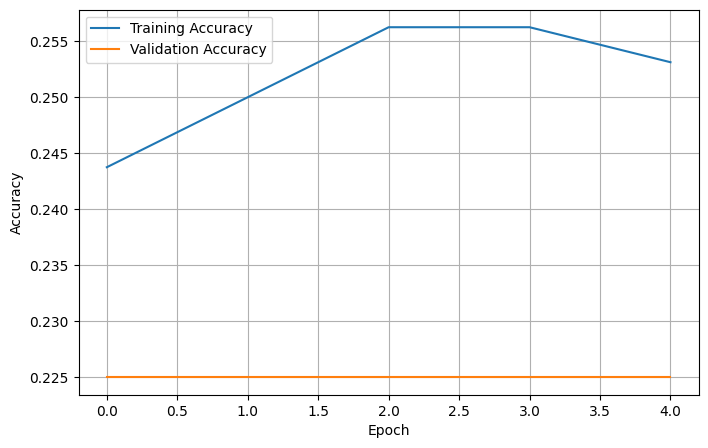

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

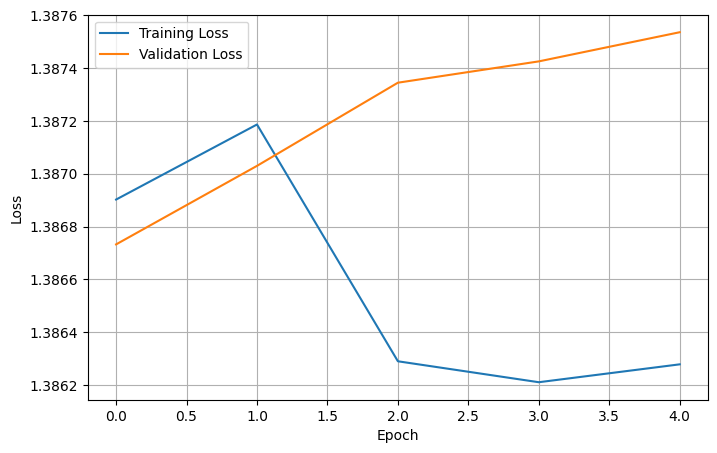

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(validation_dataset)

print("Validation Loss :", test_loss)
print("Validation Accuracy :", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.2250 - loss: 1.3870
Validation Loss : 1.3869833946228027
Validation Accuracy : 0.22499999403953552


In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

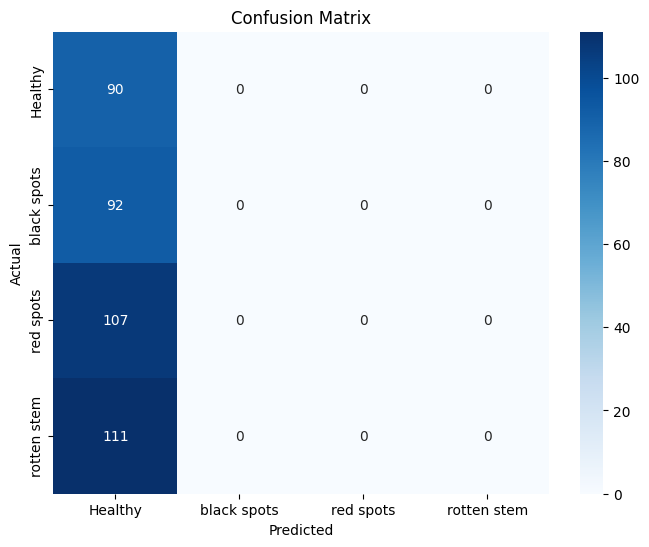

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
        y_pred,
            target_names=class_names
            ))

              precision    recall  f1-score   support

     Healthy       0.23      1.00      0.37        90
 black spots       0.00      0.00      0.00        92
   red spots       0.00      0.00      0.00       107
 rotten stem       0.00      0.00      0.00       111

    accuracy                           0.23       400
   macro avg       0.06      0.25      0.09       400
weighted avg       0.05      0.23      0.08       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving trashed-1750646457-IMG_20250522_141615.jpg to trashed-1750646457-IMG_20250522_141615.jpg


In [ ]:
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction)

print("Predicted Disease :", predicted_class)

print("Confidence :", confidence*100,"%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Disease : Healthy
Confidence : 25.21337 %
